/var/folders/61/3wm_gk5j5jvd7cv3mv31_8940000gn/T/ipykernel_16044/2844797100.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


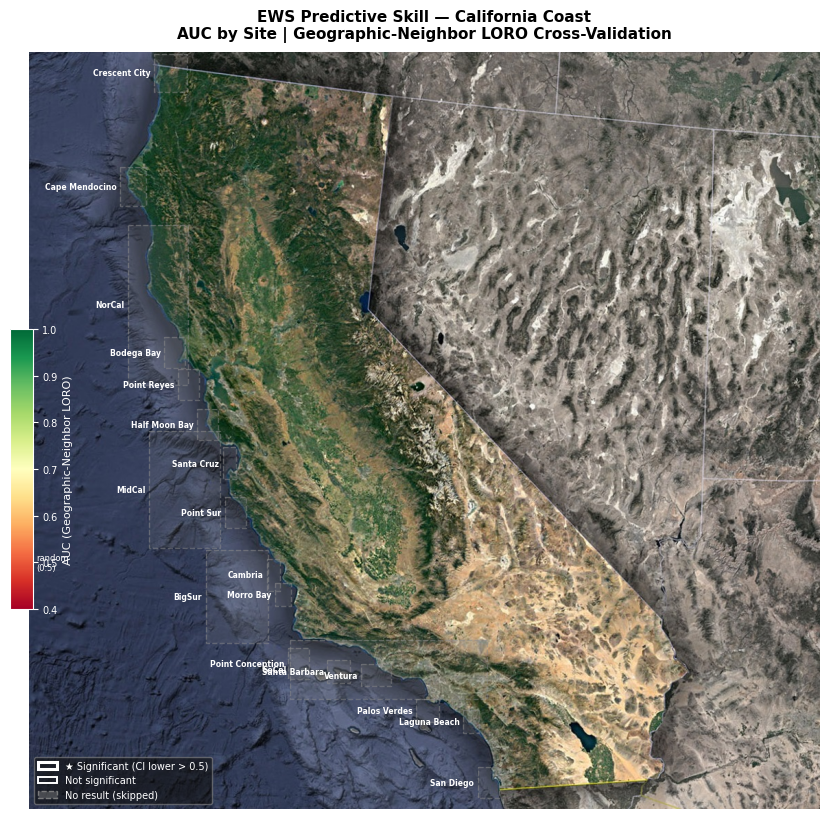

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/supplementary/california_auc_map.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colorbar import ColorbarBase
from PIL import Image
from pathlib import Path
from numpy.linalg import lstsq

# ── Load image ───────────────────────────────────────────────
IMG_PATH = Path('/Users/tonylin/Documents/kelp_project/2_NOTEBOOKS/TESTS/california coast map.jpg')
img = np.array(Image.open(IMG_PATH))
img_h, img_w = img.shape[:2]

# ── Affine calibration (same as 16_california_map.ipynb) ────
anchors_geo = [
    (41.8, -124.2),
    (38.4, -123.1),
    (36.6, -121.9),
    (34.4, -119.7),
    (32.8, -117.2),
]
anchors_px = [
    (189,   28),
    (228,  432),
    (299,  647),
    (417,  908),
    (687, 1060),
]
geo = np.array([[a[0], a[1], 1] for a in anchors_geo])
px  = np.array(anchors_px)
Ax, _, _, _ = lstsq(geo, px[:, 0], rcond=None)
Ay, _, _, _ = lstsq(geo, px[:, 1], rcond=None)

def geo_to_px(lat, lon):
    x = Ax[0]*lat + Ax[1]*lon + Ax[2]
    y = Ay[0]*lat + Ay[1]*lon + Ay[2]
    return x, y

# ── AUC results — paste your actual values from geo_neighbor_loro output ──
# Format: (name, lat_lo, lat_hi, lon_lo, lon_hi, auc, sig)
# auc = None if site was skipped (no neighbors / single class)
# sig = True if CI lower bound > 0.5
RESULTS = [
    # Training regions
    ('NorCal',           38.0, 40.0, -124.2, -122.8,  None,  False),
    ('MidCal',           36.0, 37.5, -123.2, -121.8,  None,  False),
    ('BigSur',           34.8, 36.0, -122.0, -120.8,  None,  False),
    ('SoCal',            33.8, 34.8, -120.5, -117.5,  None,  False),
    # Stress test sites — fill in your AUC values below
    ('Crescent City',    41.5, 42.0, -124.4, -123.8,  None,  False),
    ('Cape Mendocino',   40.2, 40.7, -124.5, -124.0,  None,  False),
    ('Bodega Bay',       38.2, 38.6, -123.3, -122.9,  None,  False),
    ('Point Reyes',      37.8, 38.2, -123.0, -122.6,  None,  False),
    ('Half Moon Bay',    37.3, 37.7, -122.6, -122.2,  None,  False),
    ('Santa Cruz',       36.8, 37.2, -122.1, -121.8,  None,  False),
    ('Point Sur',        36.2, 36.6, -121.9, -121.5,  None,  False),
    ('Cambria',          35.4, 35.8, -121.1, -120.8,  None,  False),
    ('Morro Bay',        35.2, 35.5, -120.9, -120.6,  None,  False),
    ('Point Conception', 34.3, 34.7, -120.5, -120.1,  None,  False),
    ('Santa Barbara',    34.2, 34.5, -119.9, -119.5,  None,  False),
    ('Ventura',          34.1, 34.4, -119.4, -118.9,  None,  False),
    ('Palos Verdes',     33.6, 33.9, -118.5, -118.1,  None,  False),
    ('Laguna Beach',     33.4, 33.7, -117.8, -117.5,  None,  False),
    ('San Diego',        32.6, 33.0, -117.4, -117.0,  None,  False),
]

# ── Colormap setup ───────────────────────────────────────────
# RdYlGn: red = low AUC (bad), yellow = mid, green = high AUC (good)
# Range 0.4 - 1.0 so that random (0.5) is clearly in the red zone
CMAP     = cm.RdYlGn
AUC_MIN  = 0.40
AUC_MAX  = 1.00
norm     = mcolors.Normalize(vmin=AUC_MIN, vmax=AUC_MAX)

def auc_to_rgba(auc, fill_alpha=0.45, edge_alpha=0.95):
    rgba = CMAP(norm(auc))
    fill = (*rgba[:3], fill_alpha)
    edge = (*rgba[:3], edge_alpha)
    return fill, edge

SKIP_COLOR  = (0.55, 0.55, 0.55)   # gray for sites with no AUC
SKIP_ALPHA_FILL = 0.15
SKIP_ALPHA_EDGE = 0.50

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, int(9 * img_h / img_w)))
fig.patch.set_visible(False)
ax.imshow(img, extent=[0, img_w, img_h, 0], aspect='equal')
ax.axis('off')

for (name, la0, la1, lo0, lo1, auc, sig) in RESULTS:
    x0, y0 = geo_to_px(la1, lo0)
    x1, y1 = geo_to_px(la0, lo1)
    w_px   = x1 - x0
    h_px   = y1 - y0
    cx     = (x0 + x1) / 2
    cy     = (y0 + y1) / 2

    if auc is None:
        fill_color = (*SKIP_COLOR, SKIP_ALPHA_FILL)
        edge_color = (*SKIP_COLOR, SKIP_ALPHA_EDGE)
        lw = 1.0
        ls = '--'
    else:
        fill_color, edge_color = auc_to_rgba(auc)
        lw = 2.2 if sig else 1.4
        ls = '-'

    # Fill
    ax.add_patch(mpatches.Rectangle(
        (x0, y0), w_px, h_px,
        linewidth=0, facecolor=fill_color, zorder=3))
    # Border — solid + thick if significant
    ax.add_patch(mpatches.Rectangle(
        (x0, y0), w_px, h_px,
        linewidth=lw, linestyle=ls,
        edgecolor=edge_color, facecolor='none', zorder=4))

    # Star marker for significant sites
    if sig:
        ax.text(cx, cy, '★',
                fontsize=7, color='white',
                ha='center', va='center', zorder=5)

    # AUC label inside box (skip if no AUC)
    if auc is not None:
        ax.text(cx, cy + (h_px * 0.28), f'{auc:.2f}',
                fontsize=5, color='white', fontweight='bold',
                ha='center', va='center', zorder=5)

    # Site name label in ocean to the left
    ax.text(x0 - 5, cy, name,
            fontsize=5.5, fontweight='bold',
            color='white' if auc is None else
                  [c for c in CMAP(norm(auc))[:3]],
            ha='right', va='center', zorder=5)

# ── Colorbar ─────────────────────────────────────────────────
# Inset axes for colorbar in the ocean (left side)
cax = fig.add_axes([0.04, 0.25, 0.025, 0.35])  # [left, bottom, width, height]
cb  = ColorbarBase(cax, cmap=CMAP, norm=norm,
                   orientation='vertical')
cb.set_label('AUC (Geographic-Neighbor LORO)', fontsize=8, color='white')
cb.ax.yaxis.set_tick_params(color='white', labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
cb.outline.set_edgecolor('white')
# Mark random baseline
cb.ax.axhline(norm(0.5), color='white', lw=1.5, ls='--')
cb.ax.text(1.15, norm(0.5), 'random\n(0.5)',
           transform=cb.ax.transAxes,
           fontsize=6, color='white', va='center')

# ── Legend for significance and skipped ──────────────────────
legend_elements = [
    mpatches.Patch(facecolor='none', edgecolor='white',
                   linewidth=2.2, label='★ Significant (CI lower > 0.5)'),
    mpatches.Patch(facecolor='none', edgecolor='white',
                   linewidth=1.4, label='Not significant'),
    mpatches.Patch(facecolor=(0.55,0.55,0.55,0.4),
                   edgecolor=(0.55,0.55,0.55,0.8),
                   linestyle='--', linewidth=1.0,
                   label='No result (skipped)'),
]
ax.legend(handles=legend_elements,
          loc='lower left', fontsize=7,
          framealpha=0.6, edgecolor='#888888',
          facecolor='#111111', labelcolor='white')

ax.set_title(
    'EWS Predictive Skill — California Coast\n'
    'AUC by Site | Geographic-Neighbor LORO Cross-Validation',
    fontsize=11, fontweight='bold', pad=10, color='black')

plt.tight_layout(pad=0)

out = Path('/Users/tonylin/Documents/kelp_project/5_FIGURES/supplementary/california_auc_map.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')